In [1]:
import polars as pl
import torch
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from model import *
from visualization import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Example: Gaussian Blops

In [17]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

### Prepare dataset

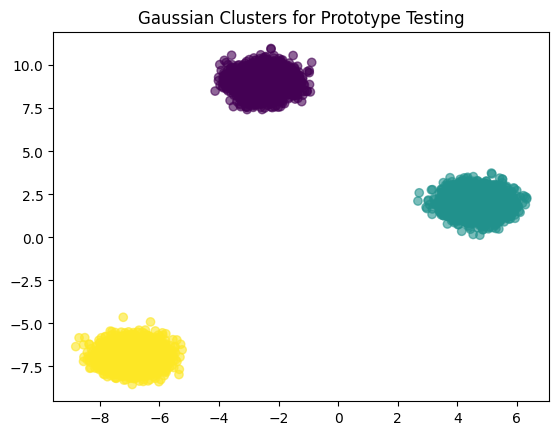

In [11]:
X, y = make_blobs(n_samples=10000, centers=3, cluster_std=0.5, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.title("Gaussian Clusters for Prototype Testing")
plt.show()

In [13]:
scaler = StandardScaler()

In [14]:
X = scaler.fit_transform(X)

In [16]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [28]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [31]:
print(len(train_loader))

250


### Prepare model

In [41]:
model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=3, num_classes=3, latent_dim=2)

In [42]:
model.encoder = nn.Identity()

In [43]:
model

ProtoPNet(
  (encoder): Identity()
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=3, out_features=3, bias=False)
)

### Train model

In [44]:
train_protopnet(model, train_loader, test_loader, epochs=5, lr=0.001, class_weights=None, lambda_clst=0.8, lambda_sep=0.08)

None

Epoch 1/5


Epoch 1/5 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 0.6582
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.23156419789791108
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.1870
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

New best model saved with Macro F1 = 1.0000

Epoch 2/5


Epoch 2/5 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: 0.0833
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.04878697472065687
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.0367
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

New best model saved with Macro F1 = 1.0000

Epoch 3/5


...

Phase 1 - Training Loss: -0.0420
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.02282617238163948
Phase 3 - Last Layer Optimization Completed
Epoch 3: Val Loss = 0.0173
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

New best model saved with Macro F1 = 1.0000

Epoch 4/5


Epoch 4/5 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.0599
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.012714784814044833
Phase 3 - Last Layer Optimization Completed
Epoch 4: Val Loss = 0.0098
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

New best model saved with Macro F1 = 1.0000

Epoch 5/5


Epoch 5/5 [Training]:   0%|          | 0/250 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.0673
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.007282881232909858
Phase 3 - Last Layer Optimization Completed
Epoch 5: Val Loss = 0.0057
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       669
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       687

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

New best model saved with Macro F1 = 1.0000


In [45]:
print(model.proto_layer.prototypes)

Parameter containing:
tensor([[-0.2010,  1.1910],
        [ 1.3155,  0.0837],
        [-1.1068, -1.2617]], requires_grad=True)


### Verify that prototypes are datapoints from training data

In [47]:
model.eval()
with torch.no_grad():
    z_test, distances, y_logits = model(X_test)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)
print(distances.shape)

(2000,)
(2000, 2)
torch.Size([2000, 3])


In [50]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()

In [51]:
model.eval()
#X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    z_train = model.encoder(X_train)
    prototypes = model.proto_layer.prototypes.detach()

# Compute L2 distances between prototypes and training latent space
dists = torch.cdist(prototypes, z_train)  # Shape: (num_prototypes, num_train_samples)

# Find closest training point for each prototype
closest_indices = torch.argmin(dists, dim=1)
closest_points = z_train[closest_indices]

distances = torch.min(dists, dim=1)[0]

for i, dist in enumerate(distances):
    print(f"Prototype {i}: Closest training point at index {closest_indices[i]}, Distance: {dist.item():.4f}")

Prototype 0: Closest training point at index 2996, Distance: 0.0000
Prototype 1: Closest training point at index 4706, Distance: 0.0000
Prototype 2: Closest training point at index 6969, Distance: 0.0000


### Visualize prototypes along with training data

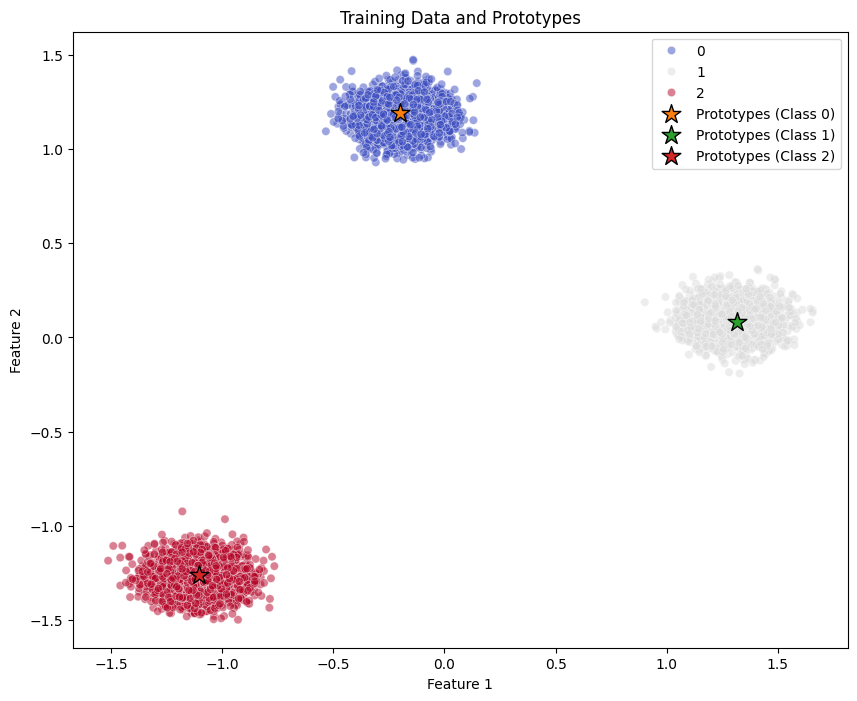

In [58]:
# Set up plot
prototype_labels = model.proto_layer.prototype_labels
plt.figure(figsize=(10, 8))

# Plot training data
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, alpha=0.5, palette="coolwarm")

# Plot prototypes
for proto_class in np.unique(prototype_labels):
    class_mask = prototype_labels == proto_class
    plt.scatter(prototypes[class_mask, 0], 
                prototypes[class_mask, 1], 
                marker='*', s=200, edgecolors='black', 
                label=f'Prototypes (Class {proto_class})')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data and Prototypes")
plt.legend()
plt.show()
